# Market Basket Analysis:
Identify which products are frequently bought together, so a retailer can act on those patterns
through shelf placement, bundling, or targeted promotions. Unlike a prediction task, the goal
here isn't a single output per customer — it's a set of interpretable rules ("customers who buy X
are more likely to also buy Y") that a product or marketing team can directly turn into decisions.

# Dataset:
The dataset used is the [Groceries dataset (Kaggle)](https://www.kaggle.com/datasets/heeraldedhia/groceries-dataset)

# Executive Summary:
We analysed 14963 real customer grocery baskets. We found 330 frequent itemsets and 18 rules with lift > 1.0. Our top 3 recommendations are: Curd and Sausages, brown bread and canned beer and frozen vegetables and sausages

In [5]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.frequent_patterns import association_rules,apriori,fpgrowth
from mlxtend.preprocessing import TransactionEncoder

In [7]:
df = pd.read_csv('/content/Groceries_dataset.csv')
df.head()

,Member_number,Date,itemDescription
0,1808,21-07-2015,tropical fruit
1,2552,05-01-2015,whole milk
2,2300,19-09-2015,pip fruit
3,1187,12-12-2015,other vegetables
4,3037,01-02-2015,whole milk


In [8]:
print(f"Shape : {df.shape}")
display(df.describe())
display(df.info())
df.isna().sum()

Shape : (38765, 3)


,Member_number
count,38765.000000
mean,3003.641868
std,1153.611031
min,1000.000000
25%,2002.000000
50%,3005.000000
75%,4007.000000
max,5000.000000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38765 entries, 0 to 38764
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Member_number    38765 non-null  int64 
 1   Date             38765 non-null  object
 2   itemDescription  38765 non-null  object
dtypes: int64(1), object(2)
memory usage: 908.7+ KB


None

,0
Member_number,0
Date,0
itemDescription,0


In [9]:
display(df['itemDescription'].value_counts())
agg_df = df.groupby(['Date','Member_number'])['itemDescription'].apply(list)
display(agg_df)
print(f"Average basket size = {agg_df.apply(len).mean()}")
print(f"Lowest basket size = {agg_df.apply(len).min()}")
print(f"Biggest basket size = {agg_df.apply(len).max()}")

,count
itemDescription,
whole milk,2502
other vegetables,1898
rolls/buns,1716
soda,1514
yogurt,1334
...,...
rubbing alcohol,5
bags,4
baby cosmetics,3


Date        Member_number
01-01-2014  1249                                        [citrus fruit, coffee]
            1381                                                  [curd, soda]
            1440                                    [other vegetables, yogurt]
            1659                      [specialty chocolate, frozen vegetables]
            1789                                     [hamburger meat, candles]
                                                   ...                        
31-10-2015  4322                                      [brown bread, chocolate]
            4675                                           [pip fruit, pastry]
            4773             [salty snack, other vegetables, yogurt, other ...
            4882                          [tropical fruit, pickled vegetables]
            4934                                           [canned beer, curd]
Name: itemDescription, Length: 14963, dtype: object

Average basket size = 2.590723785337165
Lowest basket size = 2
Biggest basket size = 11


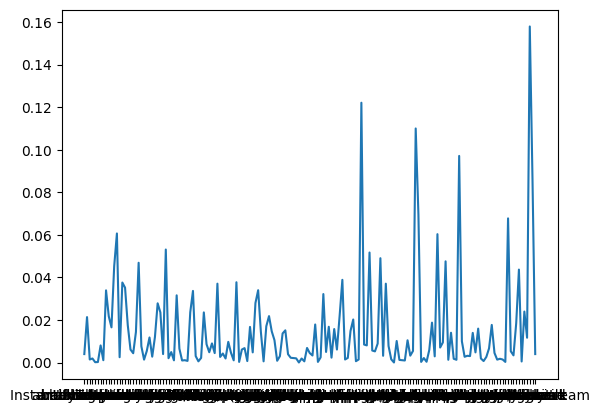

,0
Instant food products,0.004010
UHT-milk,0.021386
abrasive cleaner,0.001470
artif. sweetener,0.001938
baby cosmetics,0.000200
...,...
white bread,0.023993
white wine,0.011696
whole milk,0.157923
yogurt,0.085879


In [10]:
encoder = TransactionEncoder()
market_basket_array = encoder.fit_transform(agg_df)
market_basket = pd.DataFrame(market_basket_array,columns=encoder.columns_)
plt.plot(market_basket.mean())
plt.show()
market_basket.mean()

The Synthetic Dataset had support of around 0.3 to 0.7, whereas our current data ranges from 0.0002 to 0.015, that is, 0.02% to 1.5%. Two factors explain this: individual item support is diluted
across 167 different products, so no single item can dominate the way it could when the synthetic dataset only had 6 curated products. On top of that, since the average basket size here is only 2.6 items, any multi-item combination's support is naturally even lower than the individual items that make it up — this follows directly from the anti-monotone property, where a combination's support can never exceed the support of its smallest subset.

## Methodology

Both Apriori and FP-Growth were run on the same data and produced identical results. FP-Growth
was used for the final analysis since it runs faster on this dataset size.

`min_support` was set to 0.2%, lower than typical, because this dataset spans 167 different products — with that many options, no single product is bought often enough to support a higher
threshold.

Rules were ranked by lift rather than confidence, since lift better reflects whether two products are genuinely linked, rather than one product simply being popular on its own.

In [11]:
apriori_fi = apriori(market_basket,min_support=0.002,use_colnames=True)
display(apriori_fi)
fpg_fi = fpgrowth(market_basket,min_support=0.002,use_colnames=True)
fpg_fi.sort_values('support',ascending=False).head(15)

,support,itemsets
0,0.004010,(Instant food products)
1,0.021386,(UHT-milk)
2,0.008087,(baking powder)
3,0.033950,(beef)
4,0.021787,(berries)
...,...,...
325,0.002606,"(whole milk, waffles)"
326,0.004611,"(whole milk, whipped/sour cream)"
327,0.002941,"(whipped/sour cream, yogurt)"
328,0.003141,"(whole milk, white bread)"


,support,itemsets
20,0.157923,(whole milk)
4,0.122101,(other vegetables)
65,0.110005,(rolls/buns)
2,0.097106,(soda)
5,0.085879,(yogurt)
49,0.069572,(root vegetables)
10,0.067767,(tropical fruit)
11,0.060683,(bottled water)
12,0.060349,(sausage)
0,0.053131,(citrus fruit)


# Frequent Items:
The most frequent items bought are milk, other vegetables, and rolls or buns. Each of them has more than 10% contribution in the data set. Whole milk is around 15%, other vegetables 12%, and rolls and buns are 11%, these three items dominate by raw frequency, but high individual popularity alone doesn't imply meaningful association between them — that's exactly why the analysis moves to lift next, rather than stopping at frequency.

In [12]:
rules = association_rules(fpg_fi,metric='lift',min_threshold=1.0)
rules_sorted= rules.sort_values('lift',ascending=False)
rules_sorted

,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
3,(curd),(sausage),0.033683,0.060349,0.002941,0.087302,1.446615,1.0,9.078510e-04,1.029531,0.319493,0.032282,0.028684,0.068014
2,(sausage),(curd),0.060349,0.033683,0.002941,0.048726,1.446615,1.0,9.078510e-04,1.015814,0.328559,0.032282,0.015568,0.068014
20,(brown bread),(canned beer),0.037626,0.046916,0.002406,0.063943,1.362937,1.0,6.406768e-04,1.018191,0.276701,0.029292,0.017866,0.057613
21,(canned beer),(brown bread),0.046916,0.037626,0.002406,0.051282,1.362937,1.0,6.406768e-04,1.014394,0.279398,0.029292,0.014190,0.057613
7,(sausage),(frozen vegetables),0.060349,0.028002,0.002072,0.034330,1.225966,1.0,3.818638e-04,1.006553,0.196155,0.024012,0.006510,0.054158
6,(frozen vegetables),(sausage),0.028002,0.060349,0.002072,0.073986,1.225966,1.0,3.818638e-04,1.014726,0.189627,0.024012,0.014513,0.054158
14,(sausage),(bottled beer),0.060349,0.045312,0.003342,0.055371,1.222000,1.0,6.070623e-04,1.010649,0.193337,0.032658,0.010537,0.064559
15,(bottled beer),(sausage),0.045312,0.060349,0.003342,0.073746,1.222000,1.0,6.070623e-04,1.014464,0.190292,0.032658,0.014258,0.064559
32,(frankfurter),(other vegetables),0.037760,0.122101,0.005146,0.136283,1.116150,1.0,5.355097e-04,1.016420,0.108146,0.033261,0.016154,0.089214
33,(other vegetables),(frankfurter),0.122101,0.037760,0.005146,0.042146,1.116150,1.0,5.355097e-04,1.004579,0.118536,0.033261,0.004558,0.089214


**curd → sausage** and **sausage → curd** and other such entries show identical lift (1.45), since lift doesn't depend on
direction — but their confidence differs. since curd -> sausage has higher confidence it is the more reliable direction to act on.

## Basket Size

Basket sizes in this dataset range from 2 to 11 items, with an average of 2.6 items per basket —
every basket in the raw data already contains at least 2 items, so no baskets needed to be
filtered out.

This small average basket size is part of why the strongest lift values found here (up to 1.45)
are modest compared to a curated dataset — with most customers buying only 2–3 items per visit,
there's limited room for multi-item patterns to emerge, and most of the 330 frequent itemsets
found are pairs rather than larger combinations.

# Association Rules:

## Top 3 rules
|-|Antecedent|Consequent|Lift|
|-|-|-|-|
|1|curd|sausage|1.45|
|2|brown bread|canned beer|1.36|
|3|frozen vegetables|sausage|1.23|

## Cross-Sell Recommendations

1. **Recommendation:** when a customer buys curd, proactively place or suggest sausage nearby
   (lift = 1.45) — and vice versa, since this association holds in both directions.
2. **Recommendation:** when a customer buys brown bread, proactively suggest canned beer
   (lift = 1.36).
3. **Recommendation:** when a customer buys frozen vegetables, proactively suggest sausage
   (lift = 1.23).

## Limitations

- All transactions were weighted equally regardless of date — a production version would likely give more weight to recent purchases.
- All customers were weighted equally regardless of spend — a production version would likely prioritize patterns among higher-value customers.


## Next Steps

- Re-run this analysis on live transaction data quarterly, since purchase patterns can shift seasonally.
- Pilot the top 3 recommendations (e.g. shelf placement or a targeted promotion) and measure  actual uplift in joint purchases against the lift predicted here.